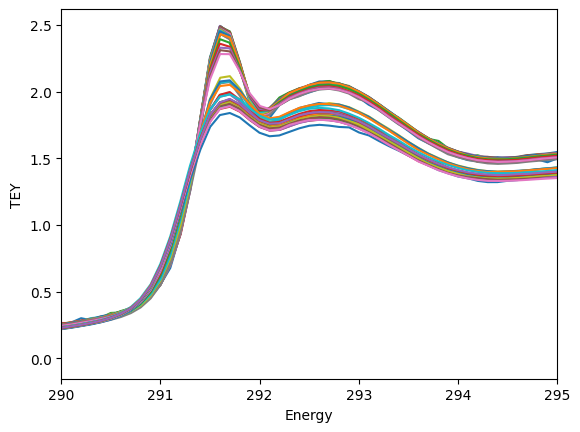

In [18]:
import pandas as pd
# Gaussian interpolation
from scipy.interpolate import interp1d

def quick_normalization(df):
    # set pre edge to 0 and post edge to 1
    pre = df.head(2)["TEY"].mean()
    post = df.tail(2)["TEY"].mean()
    df["norm"] = (df["TEY"] - pre) / (post - pre)
    return df

# Read each sheet of the energy file into a dictionary
energy_files = pd.read_excel('/home/hduva/projects/xrr_notebooks/notebooks/exploration/Exported2026-02-18_16-02-28_20260205_HOPGEnergyScans_VaryingEnergyResolution.xlsx', sheet_name=None)

energy_df = pd.DataFrame()
# create a single dataframe with all the data
for sheet_name, df in energy_files.items():
    df['scan'] = sheet_name
    df = quick_normalization(df)
    #subtract from the I0 the
    energy_df = pd.concat([energy_df, df])

import matplotlib.pyplot as plt

# Ensure 'Slits1_vsize' is treated as categorical for coloring
for name, group in energy_df.groupby('Slits1_vsize'):
    plt.plot(group['Energy'], group['norm'], label=str(name))


plt.xlabel('Energy')
plt.ylabel('TEY')
# plt.legend(title='Slits1_vsize')
plt.xlim(290, 295)
plt.show()